در این مثال داده های ۲۵ سنسور از کمپرسور گریز از مرکز مربوط به یکسال برای مدلسازی ناهنجاری استفاده می شود. هدف این مثال، ایجاد یک مدل پیش بینی شرایط غیرنرمال و اجرای آن تحت وب می باشد. 
    
دیتاست را برای مدل سازی، از آدرس زیر دانلود و در پوشه کاری قرار دهید.
    
https://github.com/hojatollahgholami/AI-in-Oil-and-gas-industry/blob/main/ex3-10/CentrifugalCompressor2022.xlsx

### نصب کتابخانه های مورد نیاز

In [1]:
!pip install seaborn joblib openpyxl fastapi requests uvicorn evidently

### فراخوانی کتابخانه های مورد نیاز

In [2]:
import pandas as pd
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# کتابخانه برای نمایش فارسی در نمودارها
import arabic_reshaper
from bidi.algorithm import get_display

# تابع کمکی برای نمایش صحیح متون فارسی در نمودارها
def fa(text):
    reshaped_text = arabic_reshaper.reshape(text)
    return get_display(reshaped_text)

# تنظیمات فارسی نویسی نمودار
plt.rcParams["font.family"] = 'Adobe Arabic' 
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams['font.size'] = 21

### بارگزاری داده و پیش پردازش

مقادیر گمشده هر ستون: 75ZI800BA.pv    0
75ZI800BB.pv    0
75ZI801BA.pv    0
75ZI801BB.pv    0
75PI808.pv      0
75PI823.pv      0
75PI870.pv      0
75PI845.pv      0
75PDI853.pv     0
75TI821.pv      0
75TI822.pv      0
75TI827.pv      0
75TI828.pv      0
75TI824.pv      0
75TI829.pv      0
75TI830.pv      0
75TI831.pv      0
75TI832.pv      0
75TI836.pv      0
75TI834.pv      0
75XI821BX.pv    0
75XI822BY.pv    0
75XI823BX.pv    0
75XI824BX.pv    0
75SI865R.pv     0
dtype: int64
اطلاعات کلی داده: (35036, 25) ,        75ZI800BA.pv  75ZI800BB.pv  75ZI801BA.pv  75ZI801BB.pv    75PI808.pv  \
count  35036.000000  35036.000000  35036.000000  35036.000000  35036.000000   
mean       0.063285      0.031087     -0.094602     -0.078653      9.878929   
std        0.029598      0.041772      0.006004      0.005007      0.664432   
min       -0.003897     -0.078966     -0.108635     -0.092039      0.000000   
25%        0.044947      0.004740     -0.098506     -0.081957      9.888927   
50%      

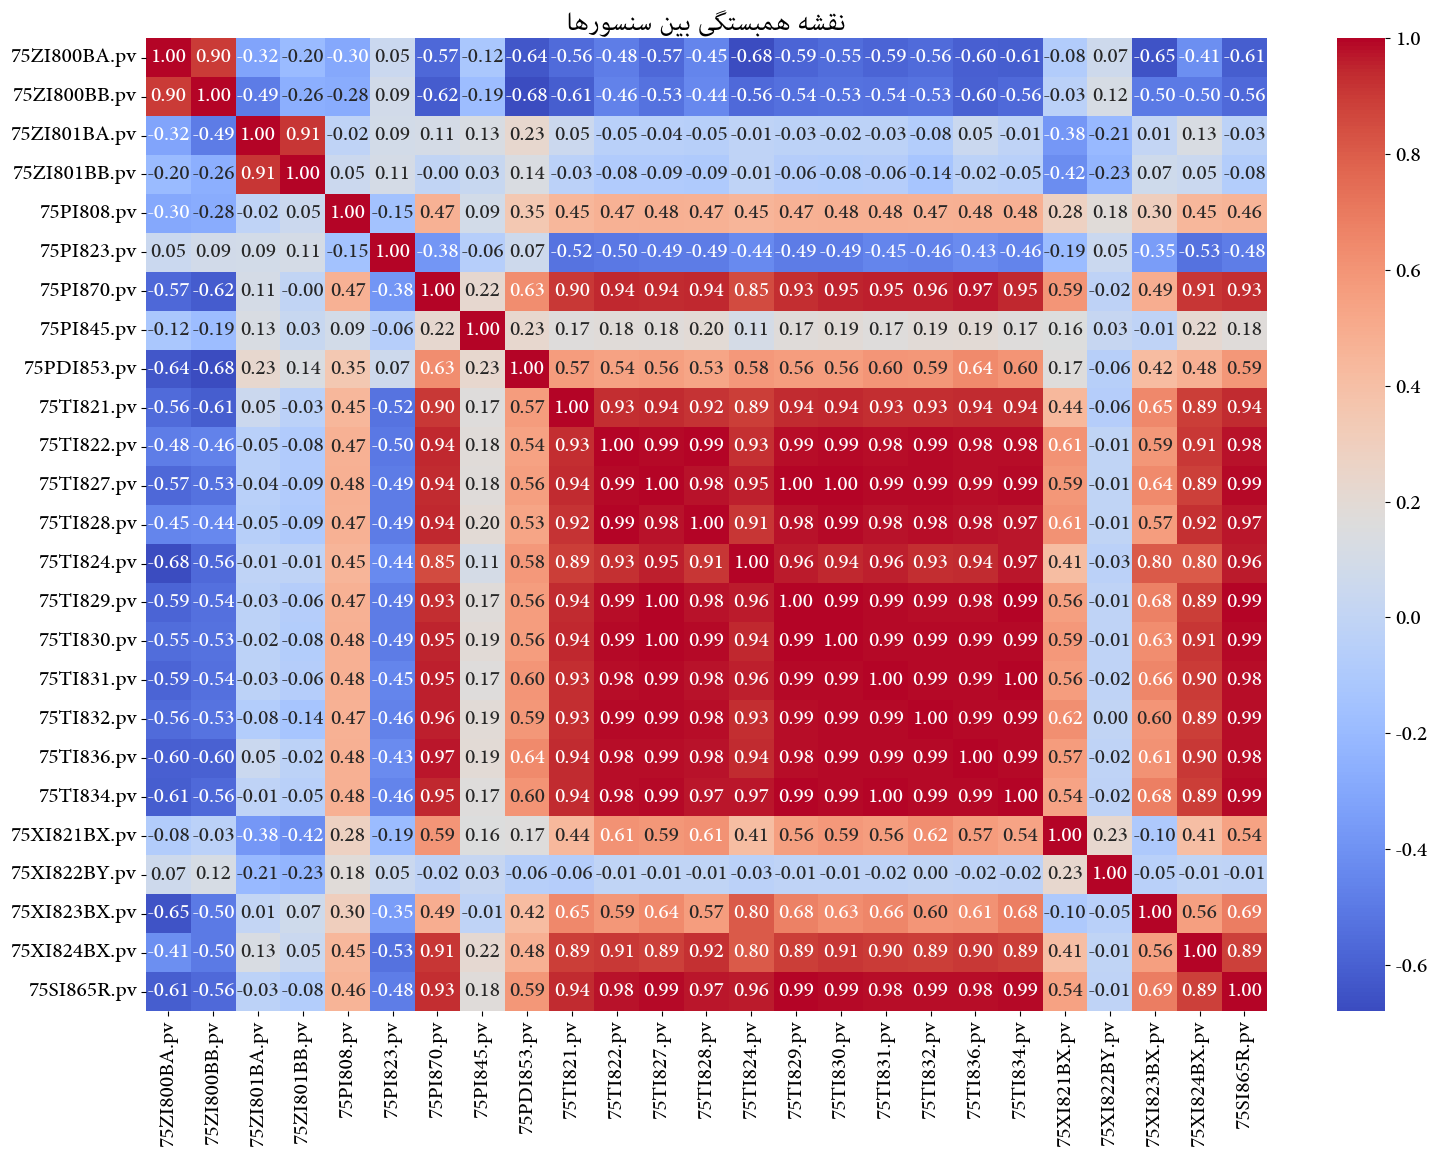

In [3]:
df = pd.read_excel("CentrifugalCompressor2022.xlsx")
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df.set_index('Timestamp', inplace=True)
print('مقادیر گمشده هر ستون:', df.isnull().sum())
df = df.interpolate(method='time')
print('اطلاعات کلی داده:',df.shape,',',df.describe())
df.head(2)

plt.figure(figsize=(16, 12))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap= 'coolwarm')
plt.title(fa('نقشه همبستگی بین سنسورها'))
plt.tight_layout()
plt.savefig('correlation_heatmap.png')
plt.show()
plt.close()

#استاندارسازی
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

### مدل سازی و ذخیره

In [4]:
model = IsolationForest(n_estimators=100,
			contamination=0.05, # فرض شده ۵درصد داده ها ناهنجار است
			random_state=42)
			
model.fit(scaled_data)

anomaly_scores = model.decision_function(scaled_data)
anomaly_pred = model.predict(scaled_data)

# افزایش نتایج به دیتاست
df['anomaly_scores'] = anomaly_scores
df['is_anomaly'] = anomaly_pred

# ذخیره مدل و استانداردسازی
joblib.dump(model, "anomaly_detection_model.pkl")
joblib.dump(scaler, "scaler.pkl")

# ذخیره داده با نتایج آنومالی
df.to_csv('compressor_data_with_anomaly.csv')

### مصورسازی

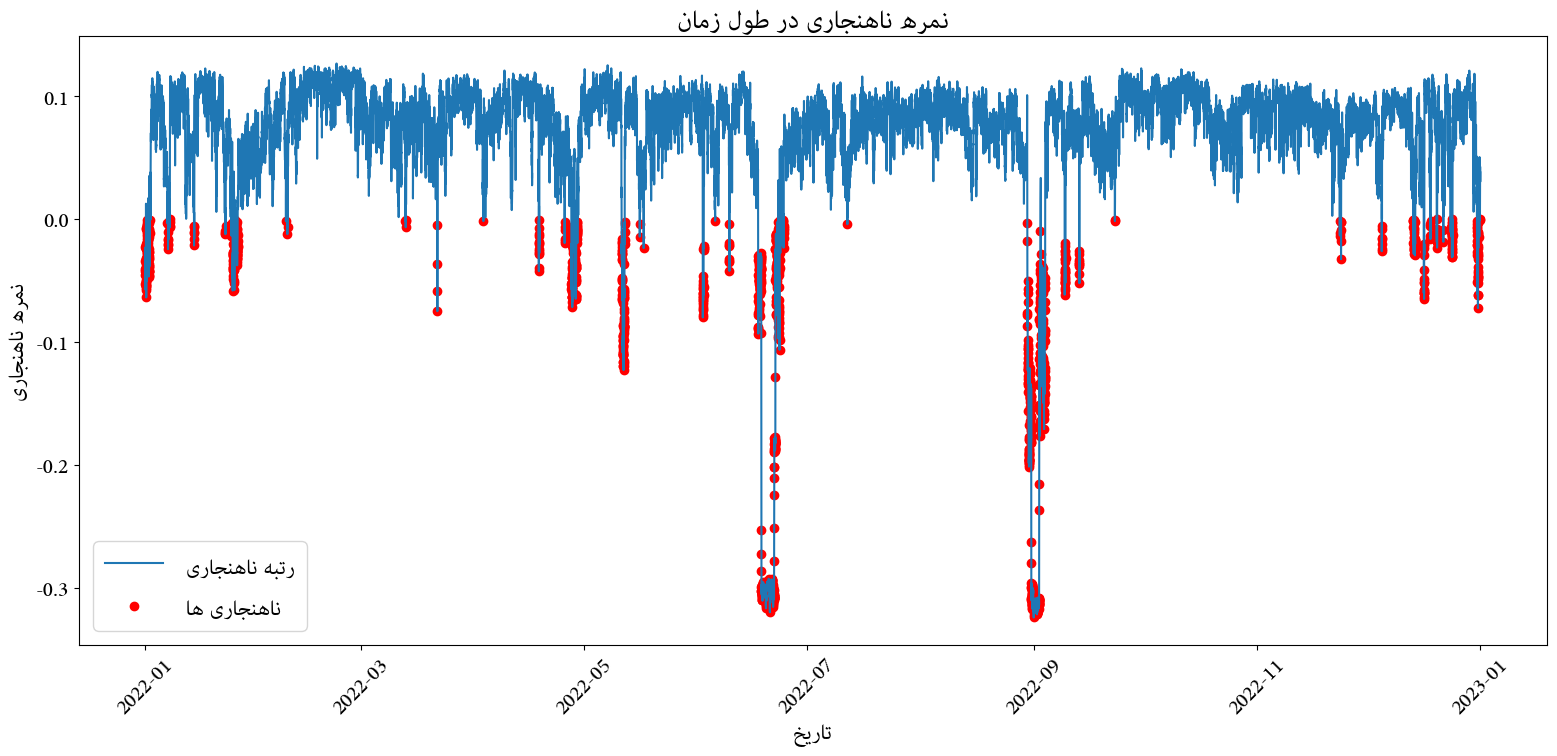

In [5]:
#نمایش ناهنجاری
plt.figure(figsize=(16, 8))
plt.plot(df.index,df['anomaly_scores'], label=fa('رتبه ناهنجاری'))
plt.scatter(df.index[df['is_anomaly'] == -1],
			df['anomaly_scores'][df['is_anomaly'] == -1],
			color='red', label=fa('ناهنجاری ها'))
plt.title(fa('نمره ناهنجاری در طول زمان'))
plt.xlabel(fa('تاریخ'))
plt.ylabel(fa('نمره ناهنجاری'))
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('anomaly_scores_over_time.png')
plt.show()
plt.close()


### برای اجرای مدل تحت وب

In [6]:
import subprocess

# اجرای FastAPI سرور
server = subprocess.Popen(
    ["uvicorn", "ex3_10_app:app", "--host", "127.0.0.1", "--port", "8000"]
)


## تا زمانی که سلول بالا در حال اجرا است، اطلاعات در آدرس های زیر در مرورگر قابل رویت است
## http://127.0.0.1:8000/health
## http://127.0.0.1:8000/docs

### بدلیل نبود دیتای سنسورها، جهت تست از ساخت داده مصنوعی استفاده می شود.

In [ ]:
import pandas as pd 
import numpy as np
import requests
import time
import joblib
import warnings


from evidently import Report
from evidently.presets import DataDriftPreset

warnings.filterwarnings('ignore')




# -----------------------
# تولید داده مصنوعی
# -----------------------
def generate_synthetic_data(original_data, num_samples=1000):
    synthetic_data = pd.DataFrame()


    for col in original_data.columns:
        if col not in ['anomaly_score', 'is_anomaly']:
            noise = np.random.normal(0, 0.1, num_samples)
            synthetic_data[col] = original_data[col].sample(num_samples, replace=True).reset_index(drop=True) + noise


    return synthetic_data




# -----------------------
# بارگذاری داده‌ها
# -----------------------
df_original = pd.read_csv('compressor_data_with_anomaly.csv', index_col=0)
df_original.index = pd.to_datetime(df_original.index)


# تولید داده مصنوعی
df_synthetic = generate_synthetic_data(df_original.drop(['anomaly_scores', 'is_anomaly'], axis=1))



# -----------------------
# بخش ۱: گزارش Evidently
# -----------------------
data_drift_report = Report([DataDriftPreset(method="psi")],include_tests="True")


my_eval = data_drift_report.run(
    reference_data=df_original.iloc[:1000],  # داده مرجع
    current_data=df_synthetic.iloc[:1000]    # داده مصنوعی
)


my_eval.save_json('data_drift_report.json')
print("✅ گزارش Evidently ذخیره شد: data_drift_report.json")





# -----------------------
# بخش ۳: ارسال داده‌ها به API
# -----------------------
API_URL = "http://127.0.0.1:8000/predict"  # مطمئن شو app.py در حال اجراست


print("🚀 شروع ارسال داده مصنوعی به API...")


for i in range(2000):  # 2000 رکورد تست
    sample = df_synthetic.iloc[i].tolist()  # یک ردیف
    try:
        resp = requests.post(API_URL, json={"sensor_data": sample})
        if resp.status_code == 200:
            print(f"[{i}] پاسخ API:", resp.json())
        else:
            print(f"[{i}] خطا:", resp.status_code, resp.text)
    except Exception as e:
        print(f"[{i}] ❌ مشکل در ارتباط با API:", e)


    time.sleep(1)  # هر ثانیه یک بار ارسال


✅ گزارش Evidently ذخیره شد: data_drift_report.json
🚀 شروع ارسال داده مصنوعی به API...
[0] پاسخ API: {'anomaly_score': -0.07480669085728903, 'is_anomaly': -1, 'anomaly_status': 'Anomlay'}
[1] پاسخ API: {'anomaly_score': 0.019691868030666748, 'is_anomaly': 1, 'anomaly_status': 'Normal'}
[2] پاسخ API: {'anomaly_score': 0.03398754806557064, 'is_anomaly': 1, 'anomaly_status': 'Normal'}
[3] پاسخ API: {'anomaly_score': -0.05385407198532183, 'is_anomaly': -1, 'anomaly_status': 'Anomlay'}
[4] پاسخ API: {'anomaly_score': -0.011633241753525592, 'is_anomaly': -1, 'anomaly_status': 'Anomlay'}
[5] پاسخ API: {'anomaly_score': 0.012356473911697752, 'is_anomaly': 1, 'anomaly_status': 'Normal'}
[6] پاسخ API: {'anomaly_score': -0.015261720399902867, 'is_anomaly': -1, 'anomaly_status': 'Anomlay'}
[7] پاسخ API: {'anomaly_score': -0.08635876126420522, 'is_anomaly': -1, 'anomaly_status': 'Anomlay'}
[8] پاسخ API: {'anomaly_score': -0.016664660191397396, 'is_anomaly': -1, 'anomaly_status': 'Anomlay'}
[9] پاسخ 